# Connect to the GIS portal

In [1]:
# Connect to the Portal
from arcgis.gis import GIS
import getpass

password = getpass.getpass("Enter password:")
portal_gis = GIS('https://dev004546.esri.com/portal', 'djohnsonRA', password)
print('Successfully connected as ' + portal_gis.properties.user.username)

Successfully connected as djohnsonRA


# Access the data for analysis

In [2]:
# Search for items tagged with 'Raster Analytics'
search_result = portal_gis.content.search(query="tags:Raster Analytics")
search_result

[<Item title:"USGS NED 30m" type:Image Service owner:djohnsonRA>,
 <Item title:"Ventura_County_FL" type:Feature Service owner:djohnsonRA>,
 <Item title:"Human Modified Index" type:Image Service owner:djohnsonRA>,
 <Item title:"Counties of the USA" type:Map Service owner:djohnsonRA>,
 <Item title:"Ventura_County" type:Map Service owner:djohnsonRA>,
 <Item title:"Ventura_County_FL" type:Service Definition owner:djohnsonRA>,
 <Item title:"Conterminous_USA_BorderMask" type:Image Service owner:djohnsonRA>]

### DEM layer

<Item title:"USGS NED 30m" type:Image Service owner:djohnsonRA>
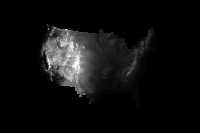

In [3]:
# Get a reference to the DEM image service item
item_dem = search_result[0]
item_dem

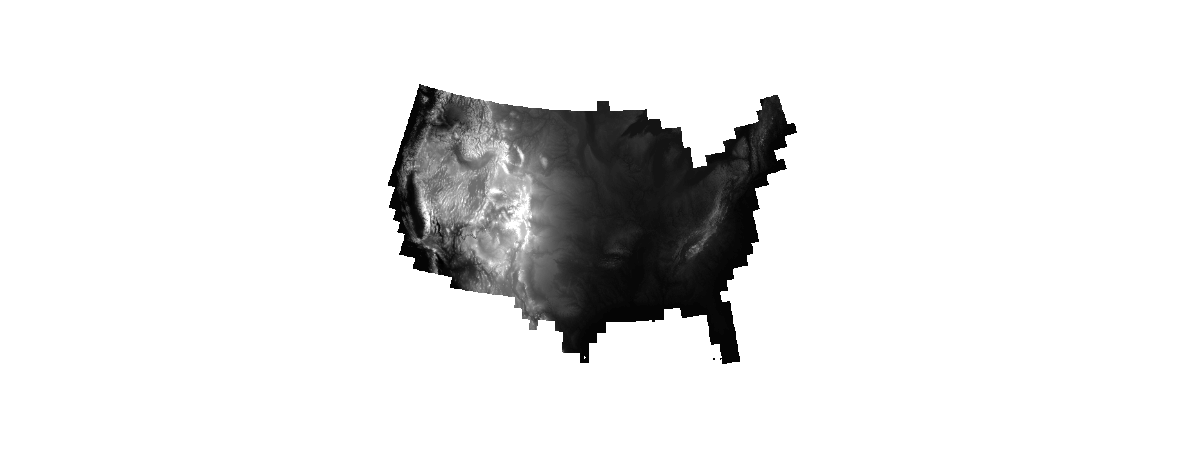

In [4]:
# Get a layer reference from the DEM image service item
lyr_dem = item_dem.layers[0]
lyr_dem

### Slope analysis layer

In [5]:
# Import the raster functions from the Python API
from arcgis.raster.functions import *

In [6]:
from arcgis.geocoding import geocode
ventura_county = geocode('Ventura County', out_sr=lyr_dem.properties.spatialReference)[0]

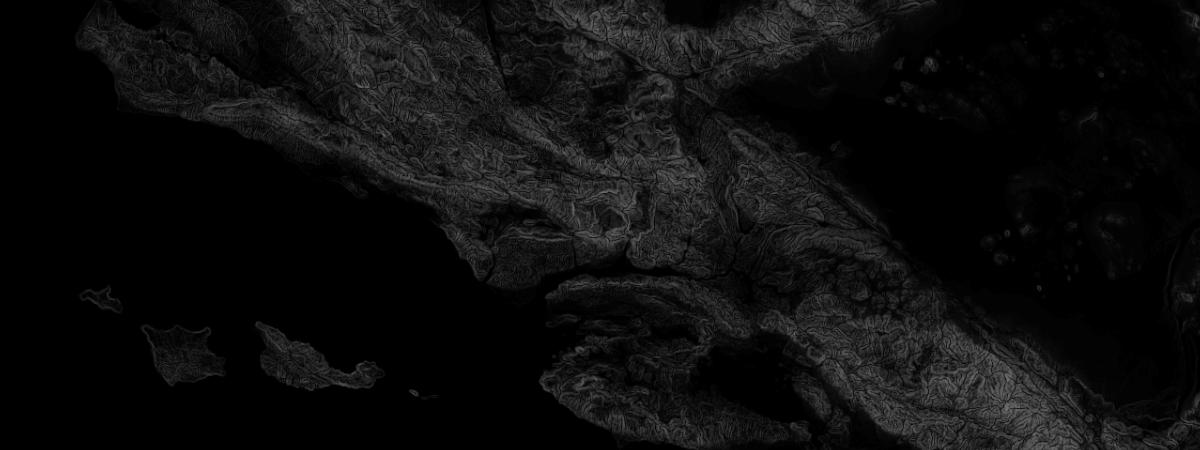

In [7]:
# Derive a slope layer from the DEM layer
lyr_slope = slope(dem=lyr_dem,slope_type='DEGREE', z_factor=1)
lyr_slope.extent= ventura_county['extent']
lyr_slope

### Human Modified Index analysis layer

<Item title:"Human Modified Index" type:Image Service owner:djohnsonRA>
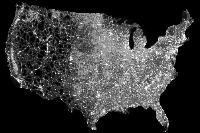

In [9]:
# Get a reference to the Human Modified Index image service item.
# This dataset is based on research on the degree of human modification to the landscape, on a scale 
# of 0 - 1, where 0.0 indicates unmodified natural landscape and 1.0 indicates the landscape is 
# completely modified by human activity.

item_hmi = search_result[2]
item_hmi

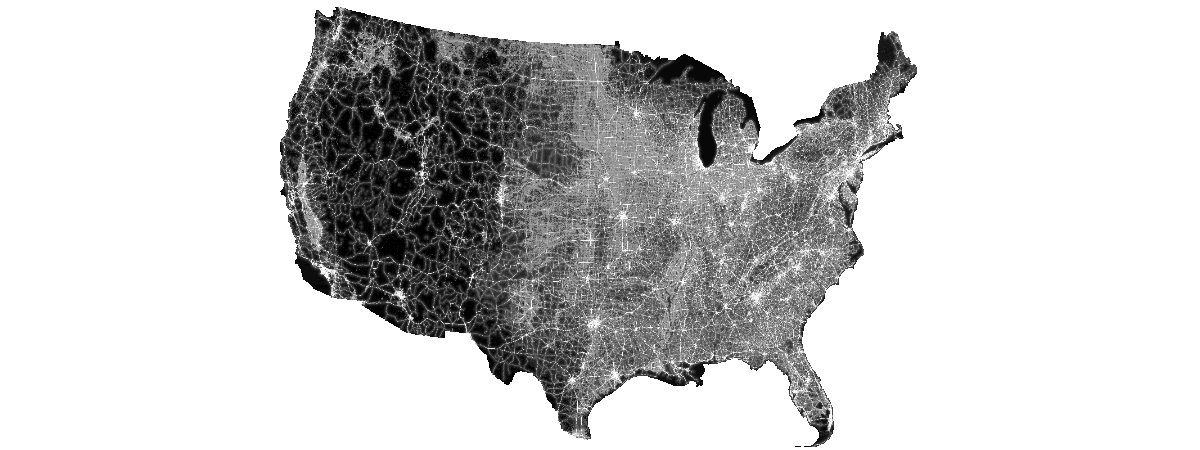

In [10]:
lyr_hmi = item_hmi.layers[0]
lyr_hmi

<Item title:"Ventura_County_FL" type:Feature Service owner:djohnsonRA>
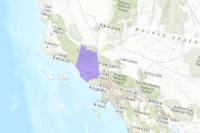

In [11]:
# Get a reference to the Ventura County feature layer item
item_vc = search_result[1]
item_vc

In [12]:
lyr_vc = item_vc.layers[0]
lyr_vc

<FeatureLayer url:"https://DEV004546.ESRI.COM/server/rest/services/Hosted/Ventura_County_FL/FeatureServer/1">

# Define an AOI for analysis

In [13]:
# Query the Ventura County layer
qry = lyr_vc.query(where='1=1')
type(qry)

arcgis.features.feature.FeatureSet

In [14]:
# Get the geometry of the feature in the Ventura County layer
geom = qry.features[0].geometry
geom

{'rings': [[[-1967842.1793999989, -370513.0398999974],
   [-1961856.9064999986, -421021.51070000045],
   [-1960578.5079999994, -435390.59769999795],
   [-1961514.9673999976, -440618.7250999976],
   [-1964837.7777999993, -439658.0892999992],
   [-1966941.1859999988, -447832.2960000001],
   [-1977348.9892999977, -445342.73069999926],
   [-1992184.0923999995, -452465.6653999984],
   [-1993599.1243999992, -457403.1242999993],
   [-2014182.7109999973, -439510.6964999996],
   [-2015866.9598999992, -428045.88249999844],
   [-2030303.3211000003, -407941.8881000001],
   [-2026866.2112000007, -406239.5462999996],
   [-2026349.7370999996, -403092.59469999745],
   [-2024360.4991999976, -401143.7042999994],
   [-2011738.9163999986, -349622.6163999997],
   [-2006579.8484000005, -350826.5583999995],
   [-2007108.5264999978, -354027.1528999973],
   [-1998770.5085999984, -356375.6348000001],
   [-1998922.714999998, -357701.8984999992],
   [-1996313.6680999994, -358501.4185999986],
   [-1997396.95859999

# Build a weighted overlay raster function

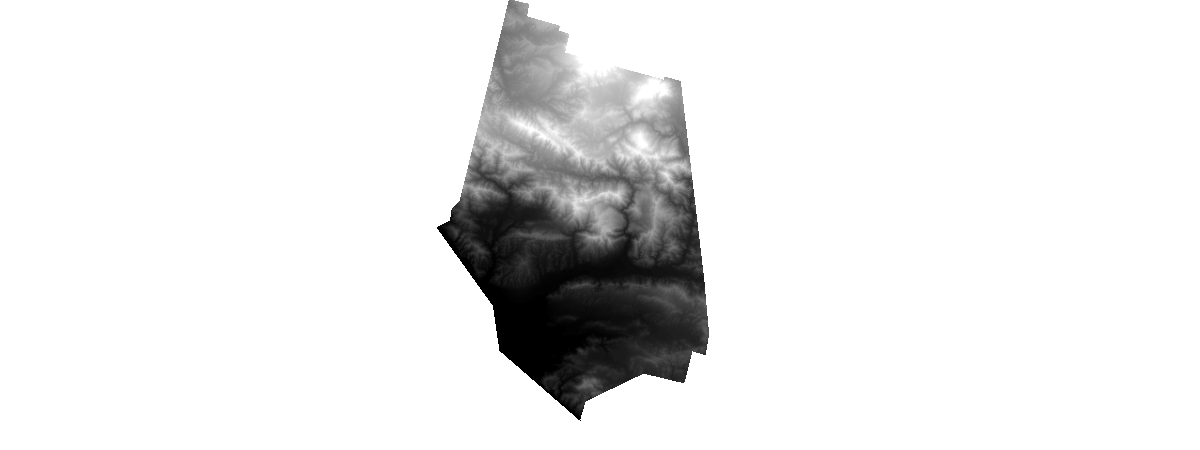

In [15]:
elev_clipped = clip(lyr_dem, geometry=geom)
elev_clipped.extent= ventura_county['extent']
elev_clipped

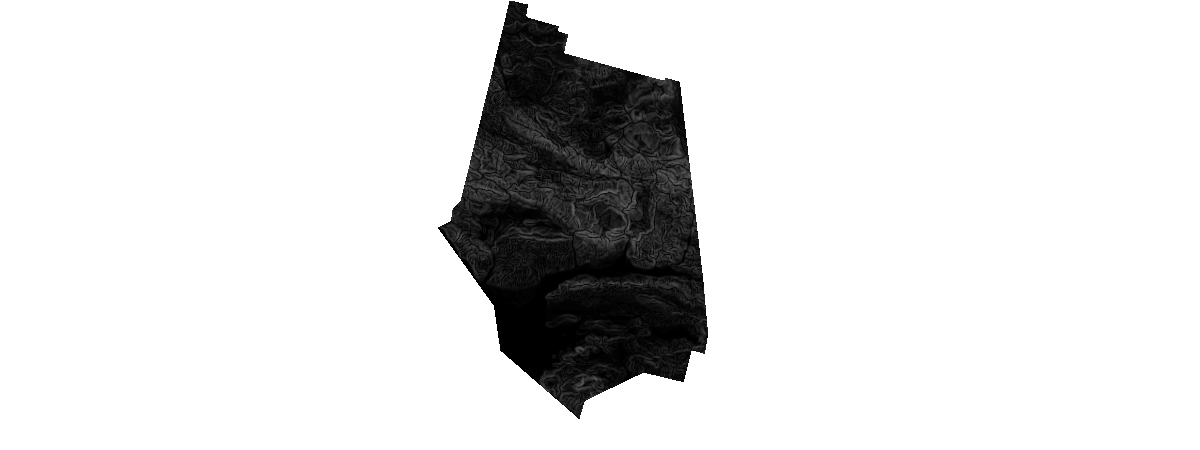

In [16]:
elev_slope = arcgis.raster.functions.slope(elev_clipped,
                                           z_factor=1, ps_power=0.664, psz_factor=0.024, remove_edge_effect=False)
elev_slope

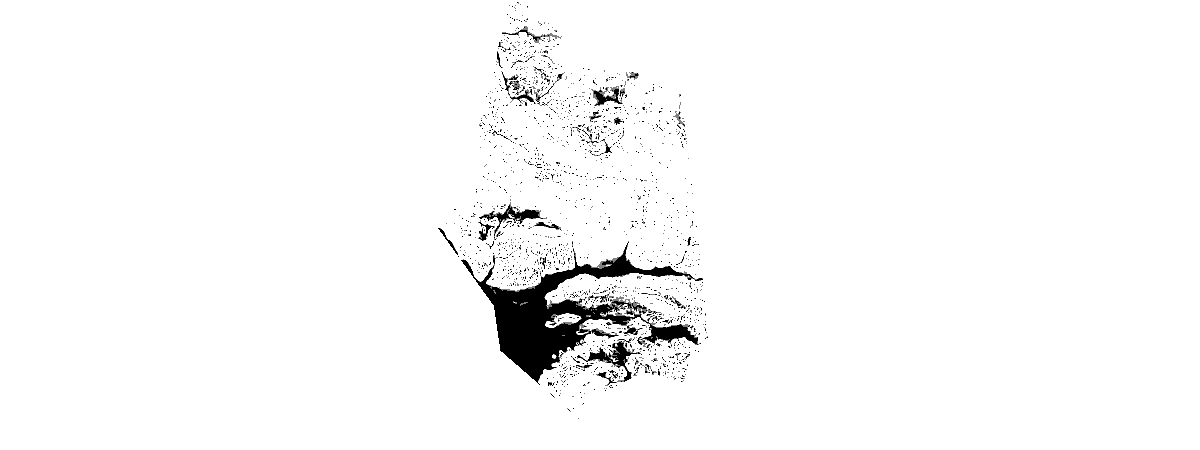

In [36]:
r1_slope = remap(raster=elev_slope, 
                        input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
                        output_values=[1,2,3,4,5,6,7,8,9]) 
r1_slope

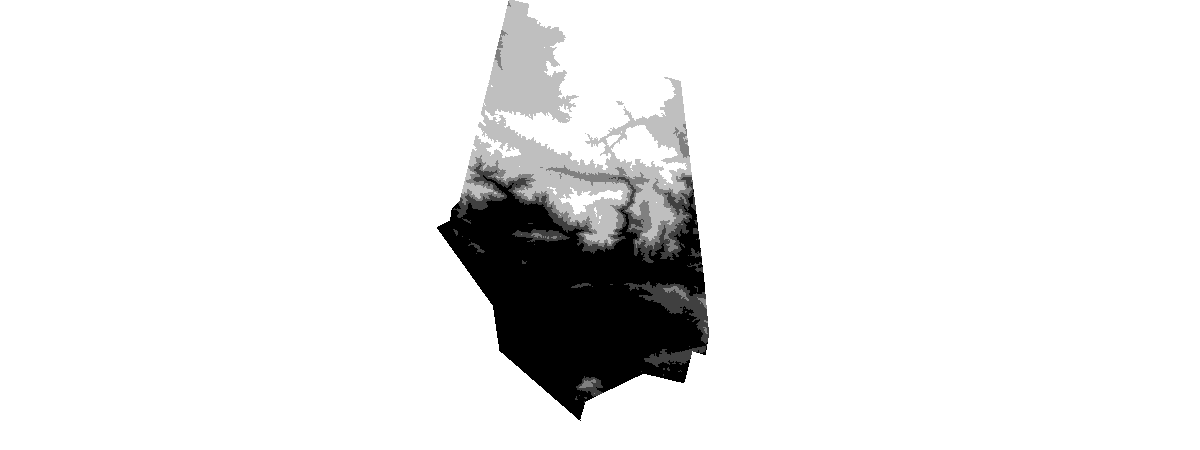

In [37]:
r2_elev = remap(raster=elev_clipped,
                       input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 
                                     1500,2000, 2000,2500, 2500,3000, 3000,5000],
                       output_values=[1,2,3,4,5,6,7,8,9])
r2_elev

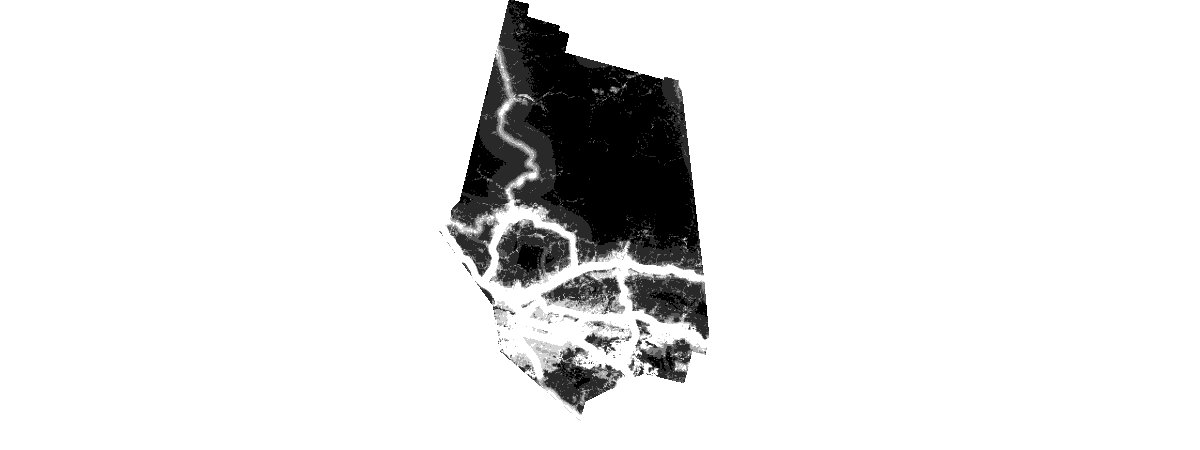

In [38]:
r3_hmi = remap(raster=clip(lyr_hmi, geometry=geom),
                                  input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,
                                                0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
                                  output_values=[1,2,3,4,5,6,7,8,9])
r3_hmi.extent = ventura_county['extent']
r3_hmi

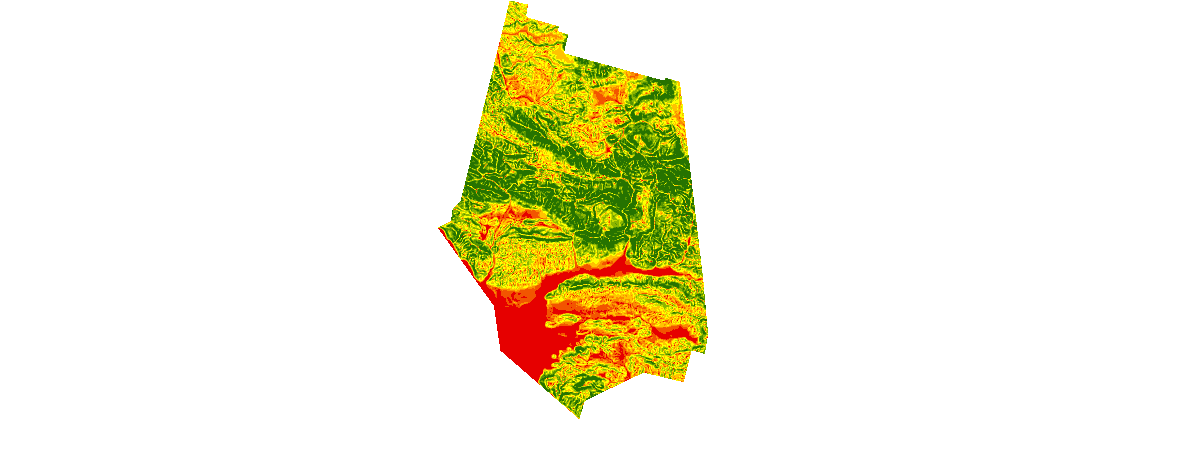

In [39]:
cmap=[[1, 230, 0, 0],[2, 242, 85, 0],[3, 250, 142, 0],[4, 255, 195, 0],
             [5, 255, 255, 0],[6, 197, 219, 0],[7, 139, 181, 0],[8, 86, 148, 0],
             [9, 38, 115, 0]]

colormap(r1_slope, colormap=cmap)

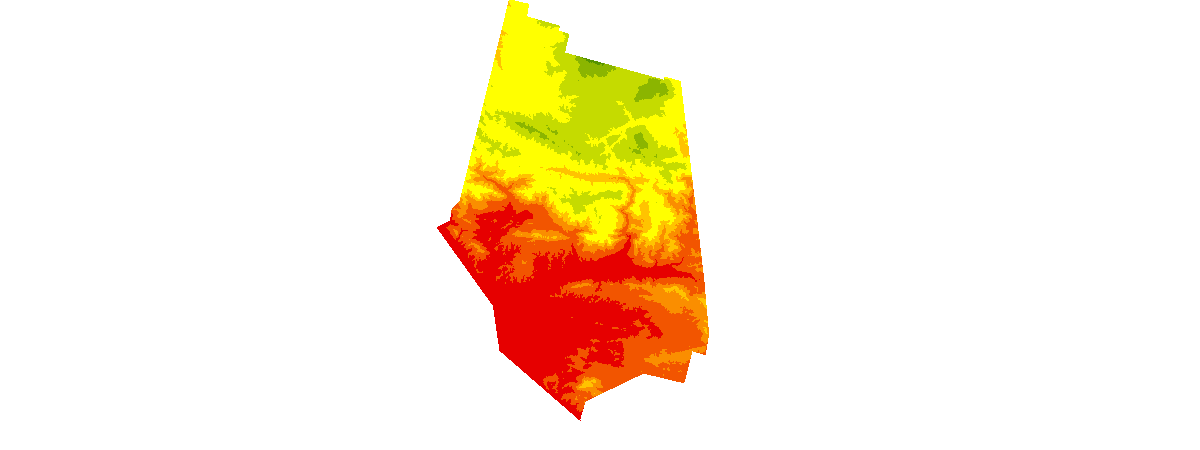

In [40]:
colormap(r2_elev, colormap=cmap)

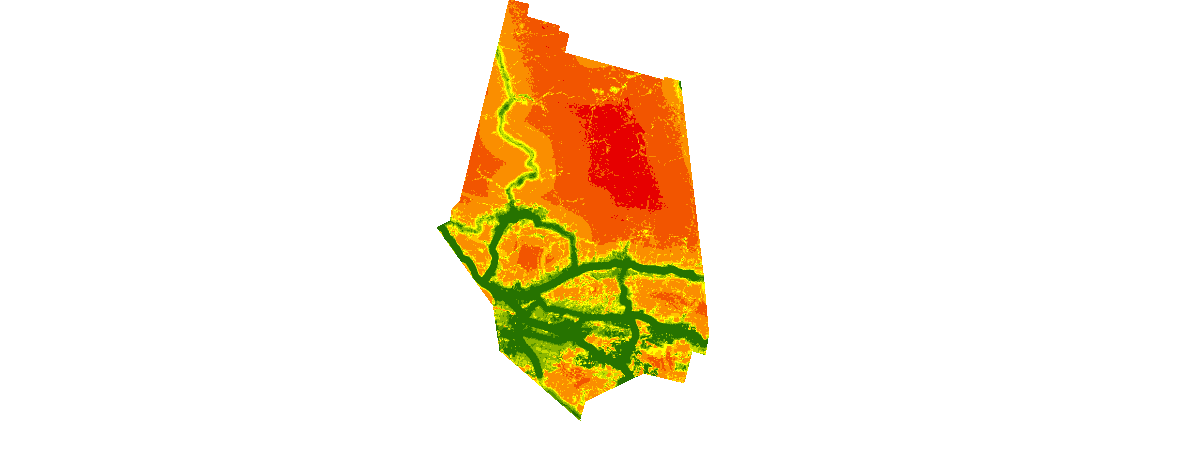

In [41]:
colormap(r3_hmi, colormap=cmap)

In [42]:
cmap2=  [[1,  38, 115,0],[2,  86, 148,0],[3,  0x8B, 0xB5,0],[4,  0xC5, 0xDB,0],
         [5, 255, 255, 0],[6,  0xFF, 0xC3,0],[7, 0xFA, 0x8E, 0],[8,  0xF2, 0x55,0],
         [9, 0xE6, 0, 0]]

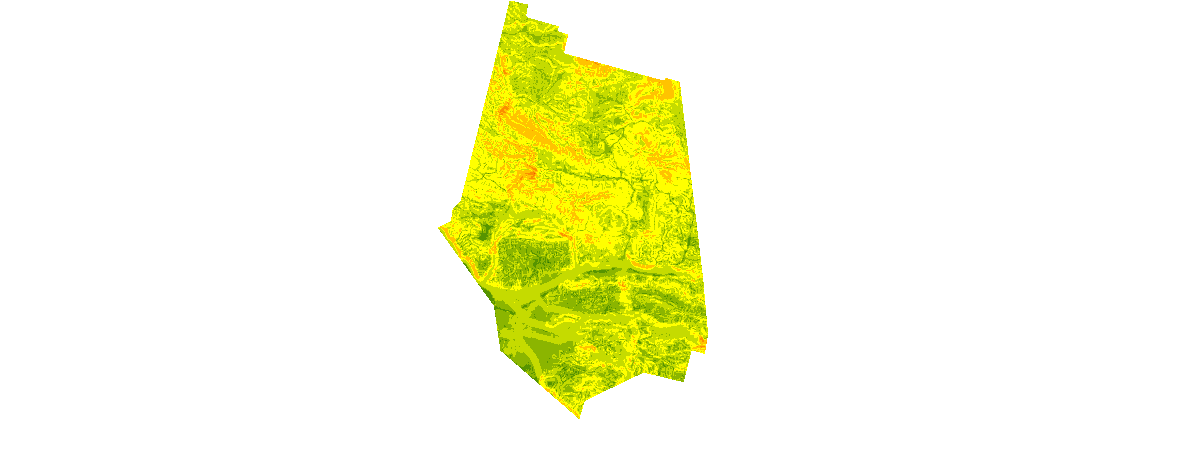

In [43]:
r_out = colormap(sum(rasters=[
                        0.34 * r1_slope,
                        0.33 * r2_elev,
                        0.33 * r3_hmi]),
                colormap=cmap2)
r_out

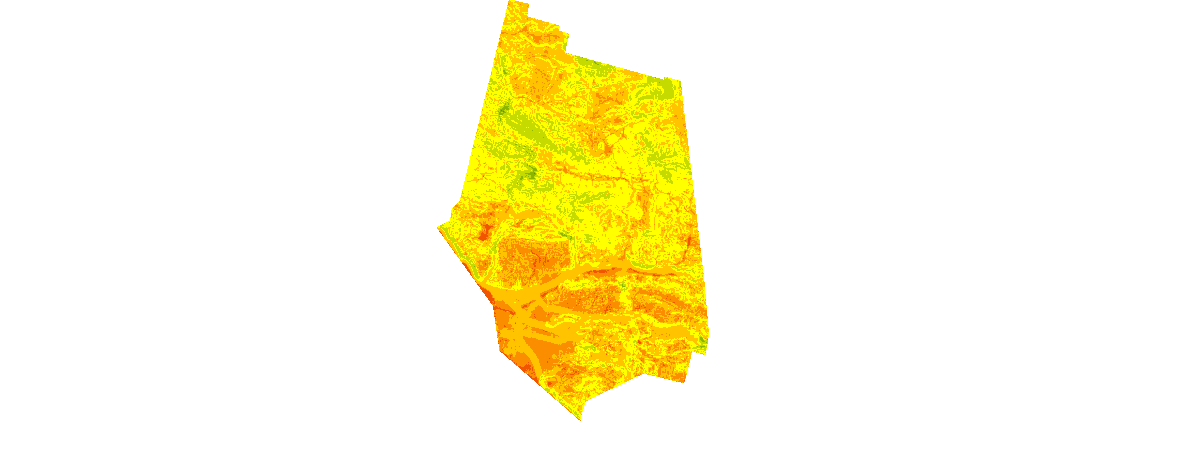

In [42]:
# ORIG FN - SAME OUTPUT AS IN SCREENSHOT

# Reclass elevation on a scale of 1-9 and apply a weight factor.
elev = remap(raster=clip(lyr_dem, geom),
             input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 
                           1500,2000, 2000,2500, 2500,3000, 3000,5000],
             output_values=[1,2,3,4,5,6,7,8,9]) * 0.33

# reclass slope on a scale of 1-9 and apply a weight factor
slope = remap(raster=clip(lyr_slope, geom),
              input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
              output_values=[1,2,3,4,5,6,7,8,9]) * 0.33

# reclass HMI on a scale of 1-9 and apply a weight factor
hmi = remap(raster=clip(lyr_hmi, geom),
            input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,
                          0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
            output_values=[1,2,3,4,5,6,7,8,9]) * 0.34

# calculate the sum of the reclassed and weighted datasets and apply a colormap to the result.
cost_surf_fxn_2 = colormap(
    raster = local(        
        rasters = 
        [
            # These tests produce the correct results.  Set the weights to 1.0
            #elev
            #slope
            #hmi
            
            # These tests produce the correct results.  Set the weights to 0.5
            #elev, slope
            #slope, elev
            
            # These tests produce correct results.  Set the weights to 0.5
            #hmi, slope
            #hmi, elev
            
            # These tests produce results that are incorrect and inconsistent with the previous two tests.
            # Note the only difference from the two above is the order of the rasters in the list.
            #slope, hmi
            #elev, hmi
            
            # Test test results produce incorrect results.  Set the weights to 0.33, 0.33, 0.34
            #hmi, elev, slope
            #hmi, slope, elev
            #slope, hmi, elev
            #slope, elev, hmi
            #elev, hmi, slope
            elev, slope, hmi

        ],
        operation=55, astype='u8'
    ),
    # The colormap is a smooth gradient from red to yellow to green.
    colormap=[[1, 230, 0, 0],[2, 242, 85, 0],[3, 250, 142, 0],[4, 255, 195, 0],
             [5, 255, 255, 0],[6, 197, 219, 0],[7, 139, 181, 0],[8, 86, 148, 0],
             [9, 38, 115, 0]]
)
cost_surf_fxn_2.extent = ventura_county['extent']
cost_surf_fxn_2

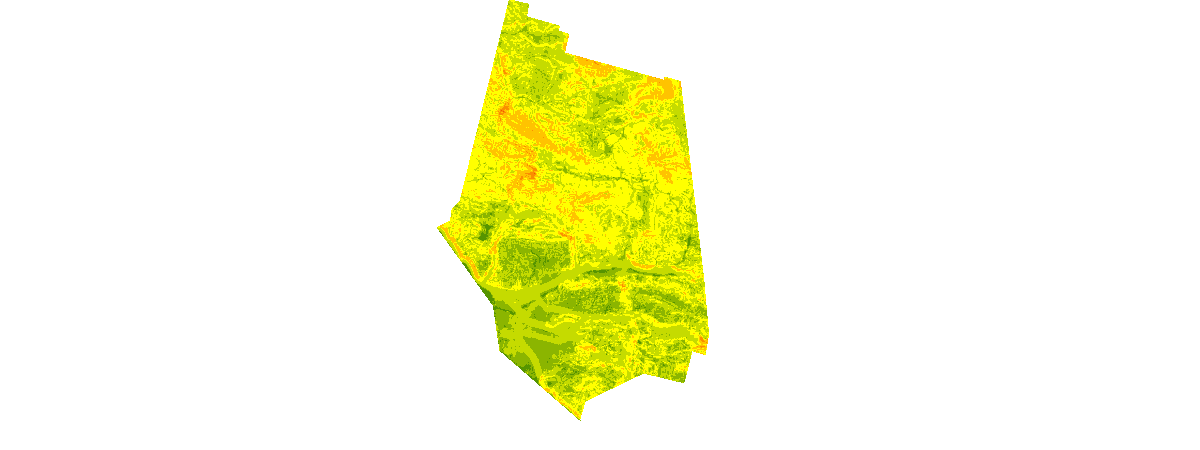

In [43]:
# INVERTED THE COLORMAP - SAME AS PRO OUTPUT

# Reclass elevation on a scale of 1-9 and apply a weight factor.
elev = remap(raster=clip(lyr_dem, geom),
             input_ranges=[-90,250, 250,500, 500,750, 750,1000, 1000,1500, 
                           1500,2000, 2000,2500, 2500,3000, 3000,5000],
             output_values=[1,2,3,4,5,6,7,8,9]) * 0.33

# reclass slope on a scale of 1-9 and apply a weight factor
slope = remap(raster=clip(lyr_slope, geom),
              input_ranges=[0,1, 1,2, 2,3, 3,5, 5,7, 7,9, 9,12, 12,15, 15,100],
              output_values=[1,2,3,4,5,6,7,8,9]) * 0.33

# reclass HMI on a scale of 1-9 and apply a weight factor
hmi = remap(raster=clip(lyr_hmi, geom),
            input_ranges=[0.0,0.1, 0.1,0.2, 0.2,0.3, 0.3,0.4, 0.4,0.5,
                          0.5,0.6, 0.6,0.7, 0.7,0.8, 0.8,1.1],
            output_values=[1,2,3,4,5,6,7,8,9]) * 0.34

# calculate the sum of the reclassed and weighted datasets and apply a colormap to the result.
cost_surf_fxn_2 = colormap(
    raster = local(        
        rasters = 
        [
            # These tests produce the correct results.  Set the weights to 1.0
            #elev
            #slope
            #hmi
            
            # These tests produce the correct results.  Set the weights to 0.5
            #elev, slope
            #slope, elev
            
            # These tests produce correct results.  Set the weights to 0.5
            #hmi, slope
            #hmi, elev
            
            # These tests produce results that are incorrect and inconsistent with the previous two tests.
            # Note the only difference from the two above is the order of the rasters in the list.
            #slope, hmi
            #elev, hmi
            
            # Test test results produce incorrect results.  Set the weights to 0.33, 0.33, 0.34
            #hmi, elev, slope
            #hmi, slope, elev
            #slope, hmi, elev
            #slope, elev, hmi
            #elev, hmi, slope
            elev, slope, hmi

        ],
        operation=55, astype='u8'
    ),
    # The colormap is a smooth gradient from red to yellow to green.
#     colormap=[[1, 230, 0, 0],[2, 242, 85, 0],[3, 250, 142, 0],[4, 255, 195, 0],
#              [5, 255, 255, 0],[6, 197, 219, 0],[7, 139, 181, 0],[8, 86, 148, 0],
#              [9, 38, 115, 0]]
    colormap=[[1,  38, 115,0],[2,  86, 148,0],[3,  0x8B, 0xB5,0],[4,  0xC5, 0xDB,0],
         [5, 255, 255, 0],[6,  0xFF, 0xC3,0],[7, 0xFA, 0x8E, 0],[8,  0xF2, 0x55,0],
         [9, 0xE6, 0, 0]]
)
cost_surf_fxn_2.extent = ventura_county['extent']
cost_surf_fxn_2